# Data understanding over the original datasets

In this notebook we examine the relationships between some common features of the original datasets. Particularly we chose to inspect only the single value features and to distinguish between continuous and descret values, for which different inspection instruments are required.

Below are defined the functions later called for each dataset:
- `_load_dataset(*)` loads the `.root` files and returns a Pandas DataFrame;
- `_correlation_heatmap(*)` shows the Pearson correlation heatmap between continuous features only;
- `_scatterplot_MET(*)` shows the relationship between the features `MET_pt` and `GenMET_pt`;
- `_data_distributions(*)` shows the distributions via histograms of the continuous features;
- `_boxplots(*)` shows the boxplot for each continuous feature to indentify outliers;
- `_data_barplots(*)` shows the barplots for each descrete feature, with `nJet` and `nGenJet` showed alongside.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import uproot

In [101]:
DATASETS = {
    "ZZTo2L2Nu": "../SkimmedDatasets/skimmed_ZZTo2L2Nu.root",
    "ZZZ": "../SkimmedDatasets/skimmed_ZZZ.root",
    "HToAATo2Mu2B": "../SkimmedDatasets/skimmed_HToAATo2Mu2B.root",
}

TREE_NAME = "Events"

FLOAT_FEATURES = [
    "MET_pt", "MET_phi", "MET_covXX", "MET_covXY", "MET_covYY",
    "MET_significance", "GenMET_pt",
    "PV_chi2", "PV_score", "PV_x", "PV_y", "PV_z",
]
INT_FEATURES = ["nSV", "nElectron", "nMuon", "nJet", "nGenJet"]

PALETTE = ["royalblue", "olivedrab", "orangered"]

In [102]:
def _load_dataset(path, tree_name):
    """
        Loads branches from a .root file and returns a Pandas DataFrame.
    """
    all_branches = FLOAT_FEATURES + INT_FEATURES
    with uproot.open(f"{path}:{tree_name}") as tree:
        df = tree.arrays(all_branches, library="pd")

    # Explicit casting
    df[FLOAT_FEATURES] = df[FLOAT_FEATURES].astype(np.float64)
    df[INT_FEATURES]   = df[INT_FEATURES].astype(np.int64)
    return df

In [103]:
def _correlation_heatmap(df, label):
    corr = df[FLOAT_FEATURES].replace([np.inf, -np.inf], np.nan).corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title(f"Correlation Heatmap - {label}")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    return

In [104]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"    Mean MET_pt: {x.mean()}, Median MET_pt: {x.median()}")
    print(f"    Mean GenMET_pt: {y.mean()}, Median GenMET_pt: {y.median()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [105]:
def _data_distributions(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=1000, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [106]:
def _boxplots(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers — {label}")

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [107]:
def _data_barplots(df, label, color):
    solo_features = ["nSV", "nElectron", "nMuon"]
    n_plots = len(solo_features) + 1
    ncols = 2
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    def draw_bar(ax, feat):
        vals = df[feat].dropna()
        bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
        centers = (bins[:-1] + bins[1:]) / 2
        counts, _ = np.histogram(vals, bins=bins)
        ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)

    for idx, feat in enumerate(solo_features):
        ax = axes[idx]
        draw_bar(ax, feat)
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel("Counts", fontsize=10)
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    # nJet vs nGenJet - combined plot
    ax_pair = axes[len(solo_features)]
    all_jet = pd.concat([df["nJet"], df["nGenJet"]]).dropna()
    bins = np.arange(int(all_jet.min()), int(all_jet.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    width = 0.8 / 2

    for i, (feat, hatch, alpha) in enumerate([("nJet", "", 0.75), ("nGenJet", "//", 0.45)]):
        counts, _ = np.histogram(df[feat].dropna(), bins=bins)
        offset = (i - 1 + 0.5) * width
        ax_pair.bar(centers + offset, counts, width=width * 0.9,
                    color=color, alpha=alpha, hatch=hatch,
                    edgecolor="grey", linewidth=0.4,
                    label=f"{label} — {feat}")
        x_ticks = np.arange(int(all_jet.min()), int(all_jet.max()) + 1)
        ax_pair.set_xticks(x_ticks)

    ax_pair.set_xlabel("n", fontsize=10)
    ax_pair.set_ylabel("Counts", fontsize=10)
    ax_pair.set_title("nJet vs nGenJet", fontsize=11, fontweight="bold")
    ax_pair.legend(fontsize=7, ncol=2)
    ax_pair.grid(axis="y", alpha=0.3)

    for j in range(len(solo_features) + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

---

## ZZTo2L2Nu dataset

In this event a pair of Z bosons decays in a pair of leptons and a pair of neutrinos. The MET values are mostly due to the latter decay, given that the neutrinos are invisble and the MET is the only means to recognize them.

Given the underlying physics of this process we expect:
- higher values of `MET_pt`;
- processes with either 2 Electrons or 2 Muons;
- no significant number of Jets (the ones that are present, are probably due to secondary processes);
- no relevant number of secondary vertices.

Given the knowledge that we have on this dataset, we chose it because we expect the ML model to perform well on it.

In [108]:
label = list(DATASETS.items())[0][0]
path = DATASETS.get("ZZTo2L2Nu")
color = PALETTE[0]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset ZZTo2L2Nu:
    17 features x 168000 events


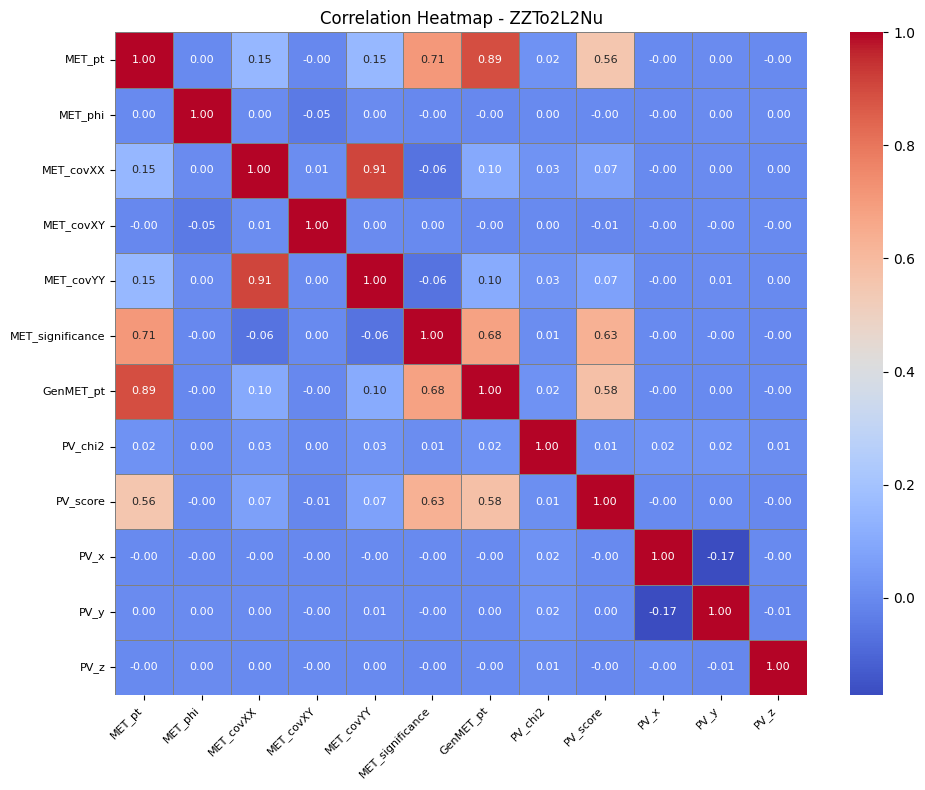

In [109]:
_correlation_heatmap(df, label)

Statistics for dataset ZZTo2L2Nu:
    Mean MET_pt: 54.3770741956658, Median MET_pt: 42.397621154785156
    Mean GenMET_pt: 46.83678087016514, Median GenMET_pt: 34.03125


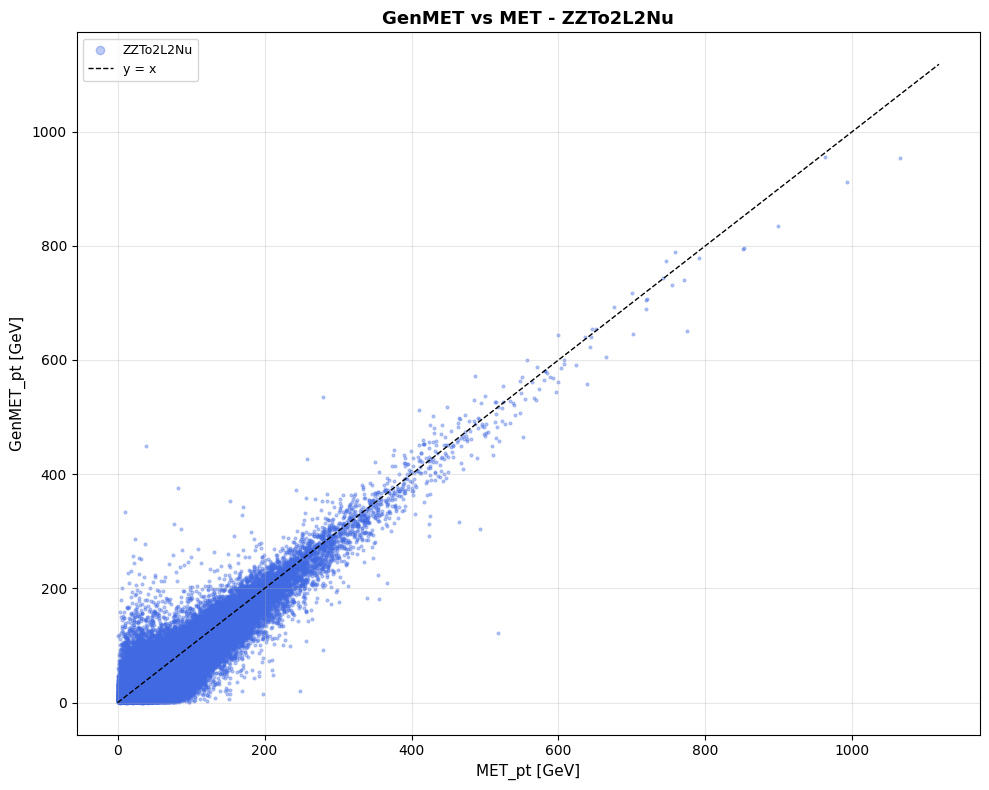

In [110]:
_scatterplot_MET(df, label=label, color=color)

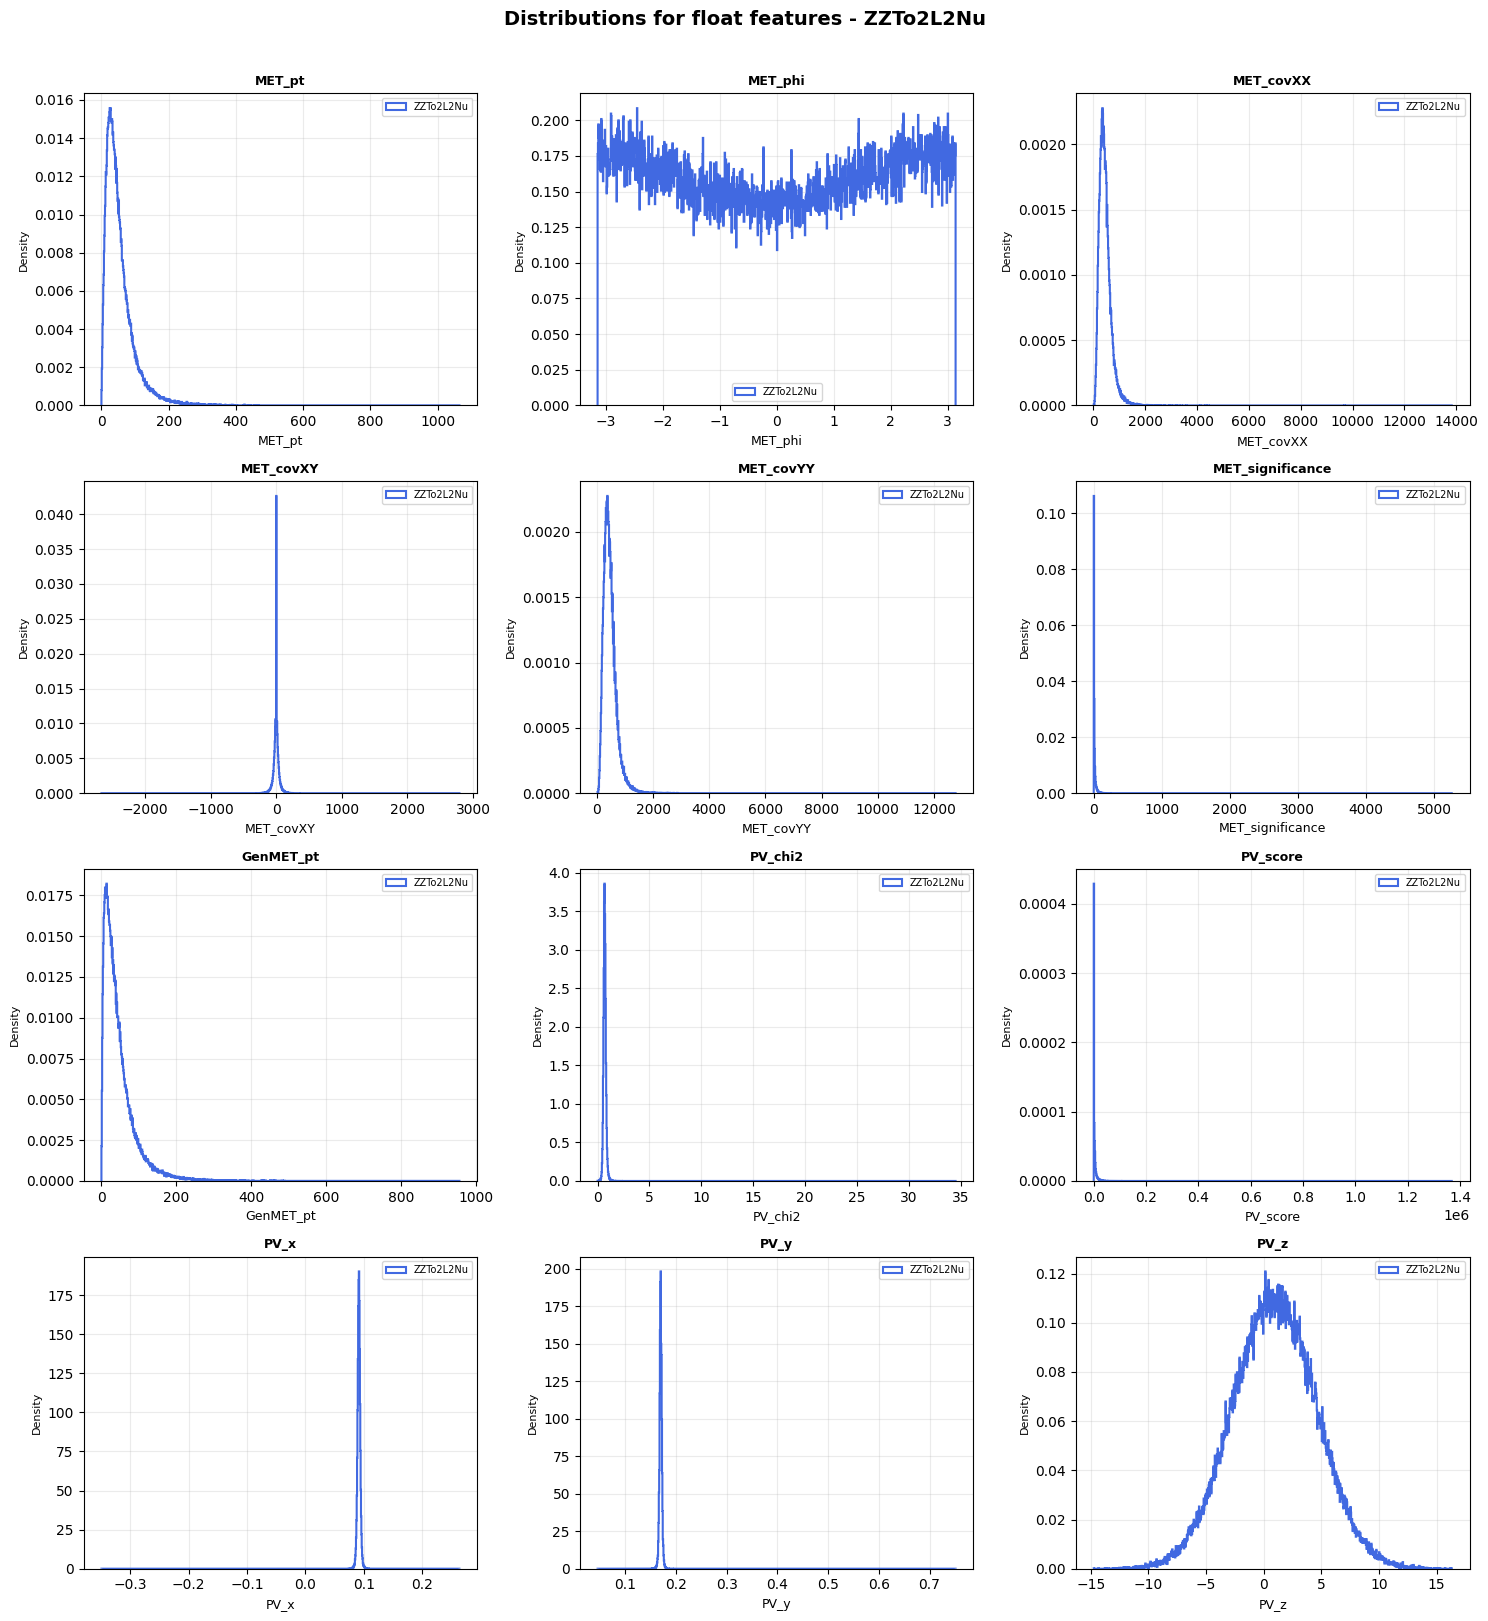

In [111]:
_data_distributions(df, label=label, color=color)

Outliers — ZZTo2L2Nu
  MET_pt                 8875 outliers (5.28%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX              5810 outliers (3.46%)
  MET_covXY             18397 outliers (10.95%)
  MET_covYY              5922 outliers (3.52%)
  MET_significance      17518 outliers (10.43%)
  GenMET_pt              9224 outliers (5.49%)
  PV_chi2                5164 outliers (3.07%)
  PV_score              16610 outliers (9.89%)
  PV_x                   5303 outliers (3.16%)
  PV_y                   5506 outliers (3.28%)
  PV_z                   1146 outliers (0.68%)


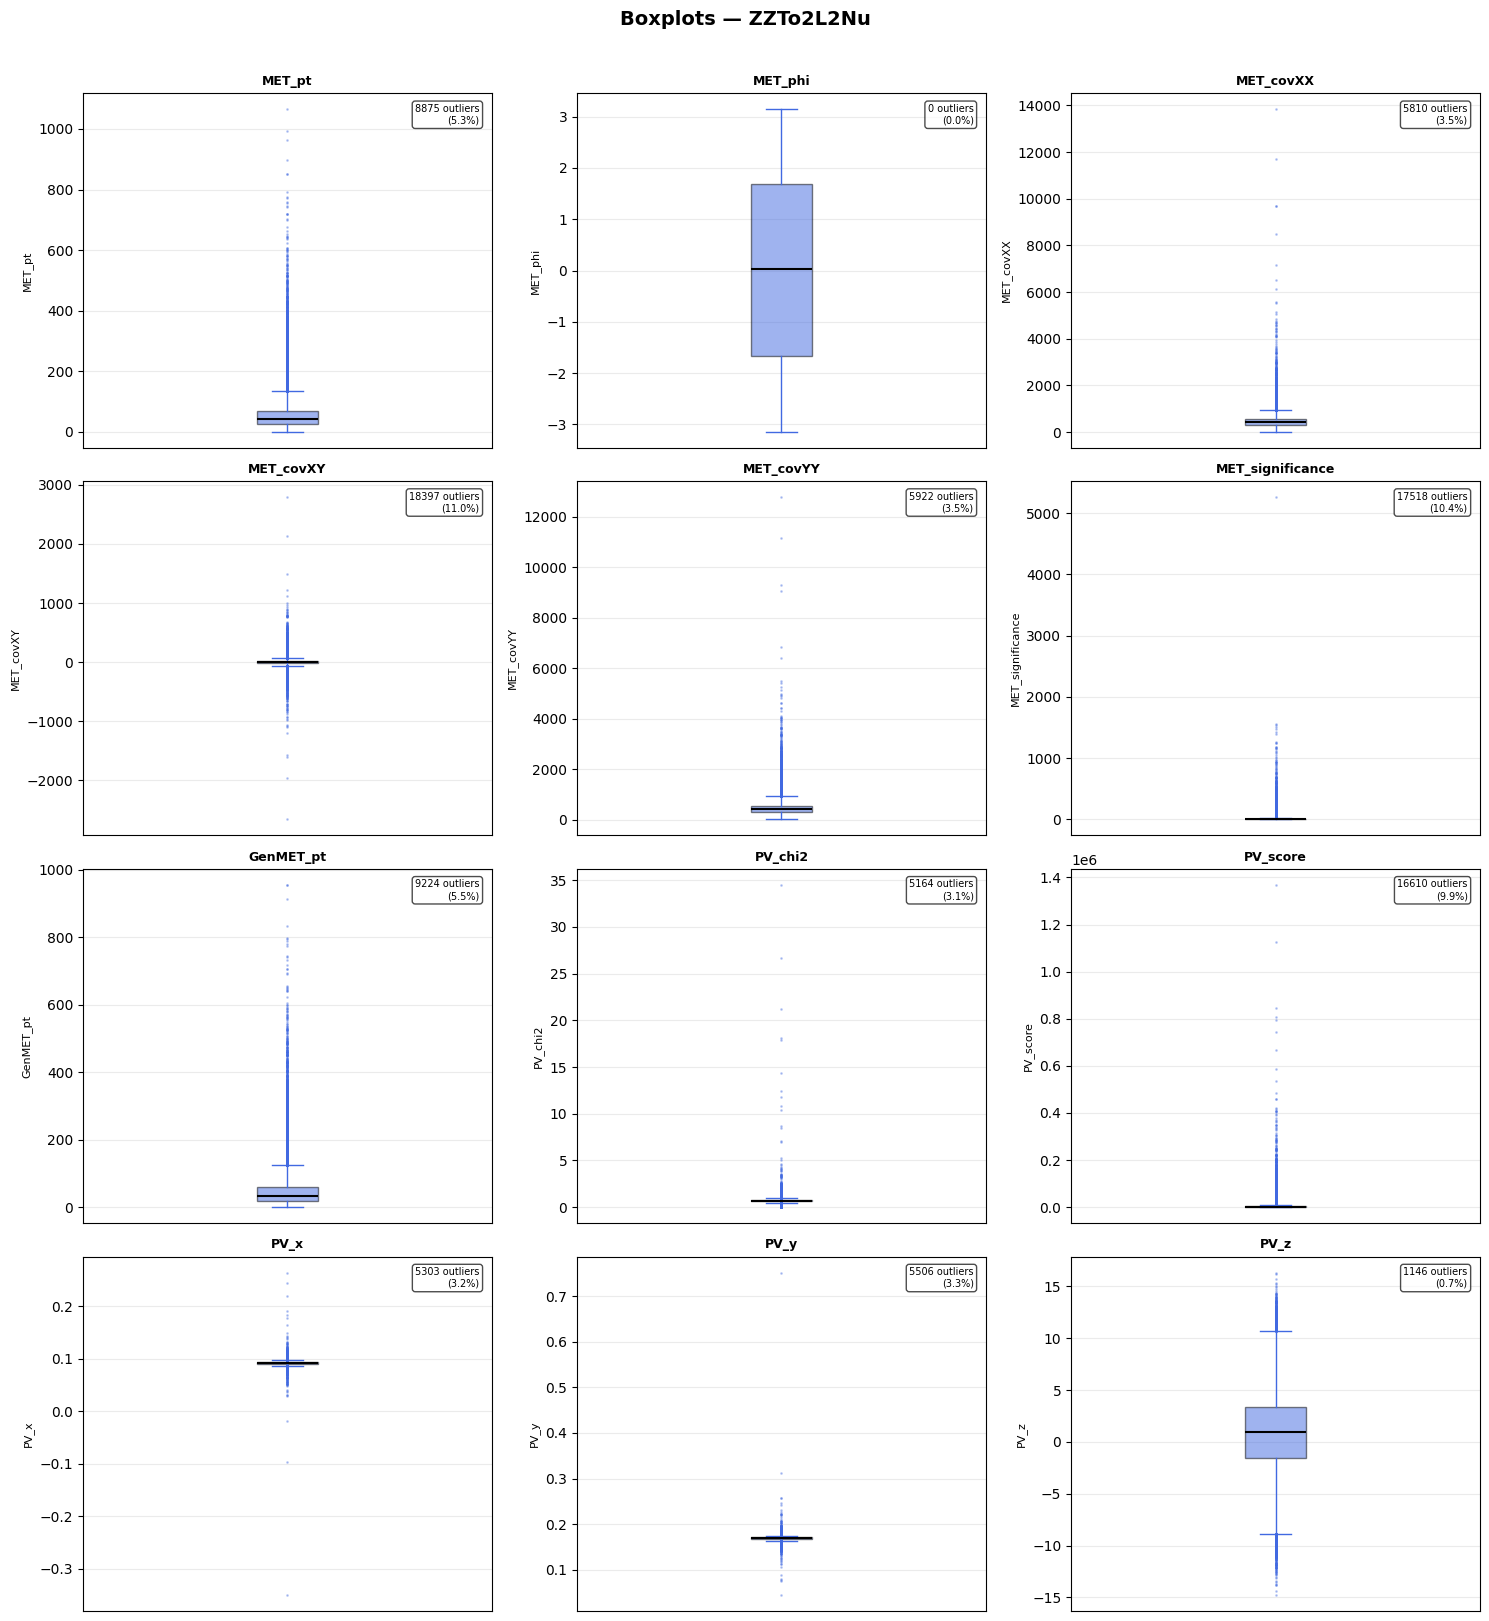

In [112]:
_boxplots(df, label=label, color=color)

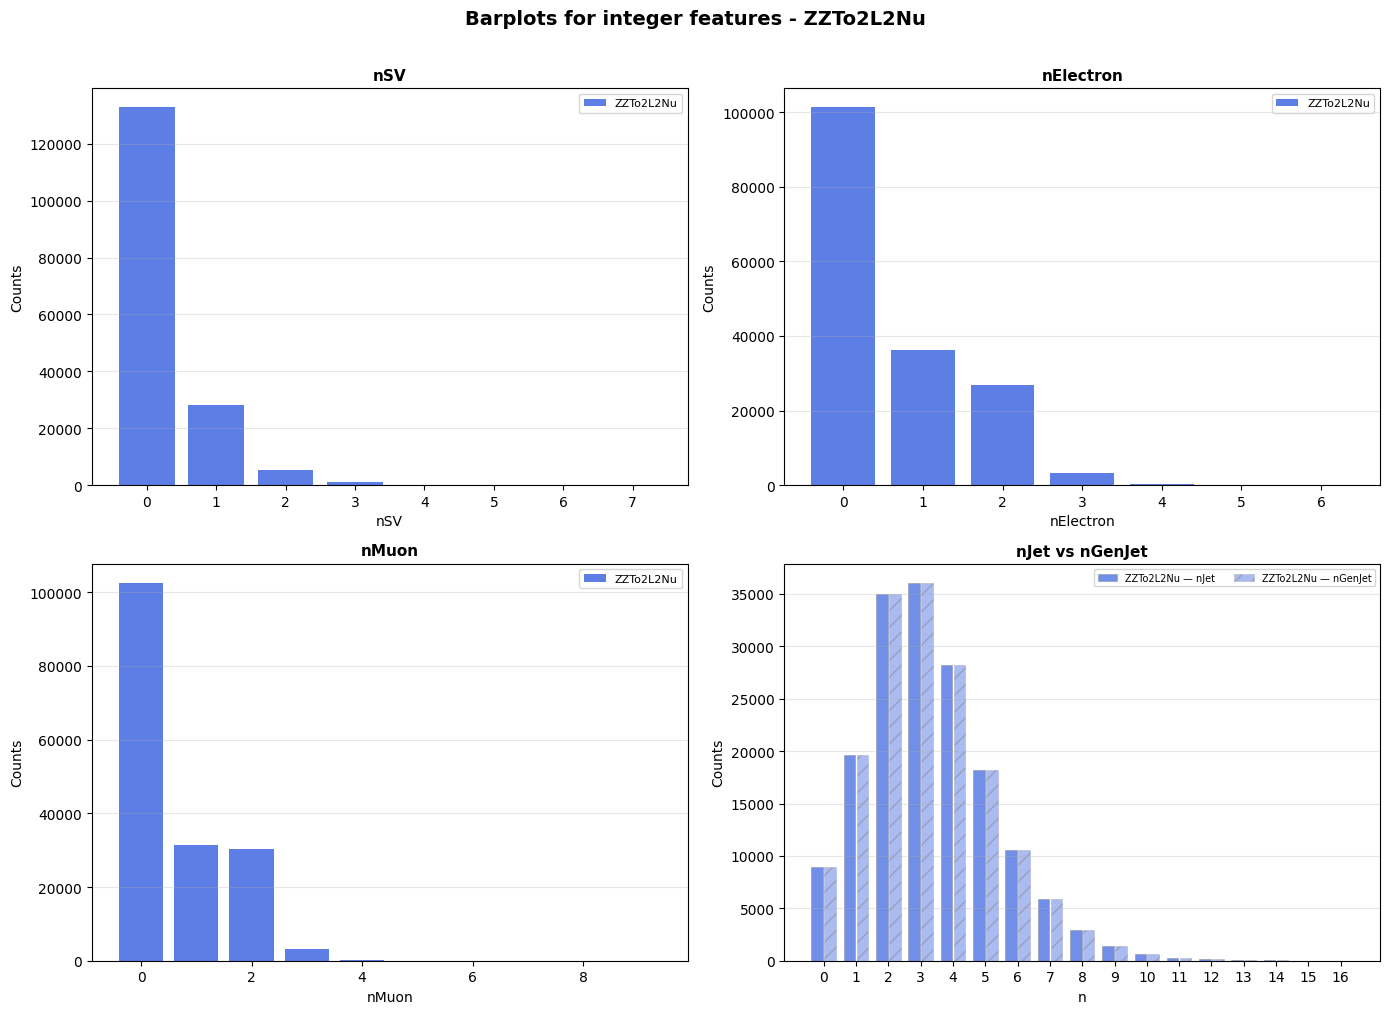

In [113]:
_data_barplots(df, label=label, color=color)

As we can see from the barplot, most of the observed events don't observe any of the expected particles; also sometimes a single particle is observed which is equally incorrect. As expected instead, the number of events where a couple of Electrons in observed, is equal to events where there's a couple of Muons; this is in accord with the theory, where the two types of decay have the same probability (50%).

Furthermore, all the other observations clearly depend on the events that we observe. It will be then necessary to clean the dataset from undesired events and later from outliers.

---

## ZZZ dataset

In this process each Z boson decays with a certain probability either into a couple of leptons or a pair of neutrinos. Given this uncertanty, the MET values tend to vary from lowe to higher scales.

In general what we can expect is:
- presence of pairs of leptons;
- varying values of MET;
- no relevant Jets;
- no relevant SV.

This dataset is of interest because we don't necessarly know its outcome, so it is interesting to test the ML model.

In [114]:
label = list(DATASETS.items())[1][0]
path = DATASETS.get("ZZZ")
color = PALETTE[1]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset ZZZ:
    17 features x 120000 events


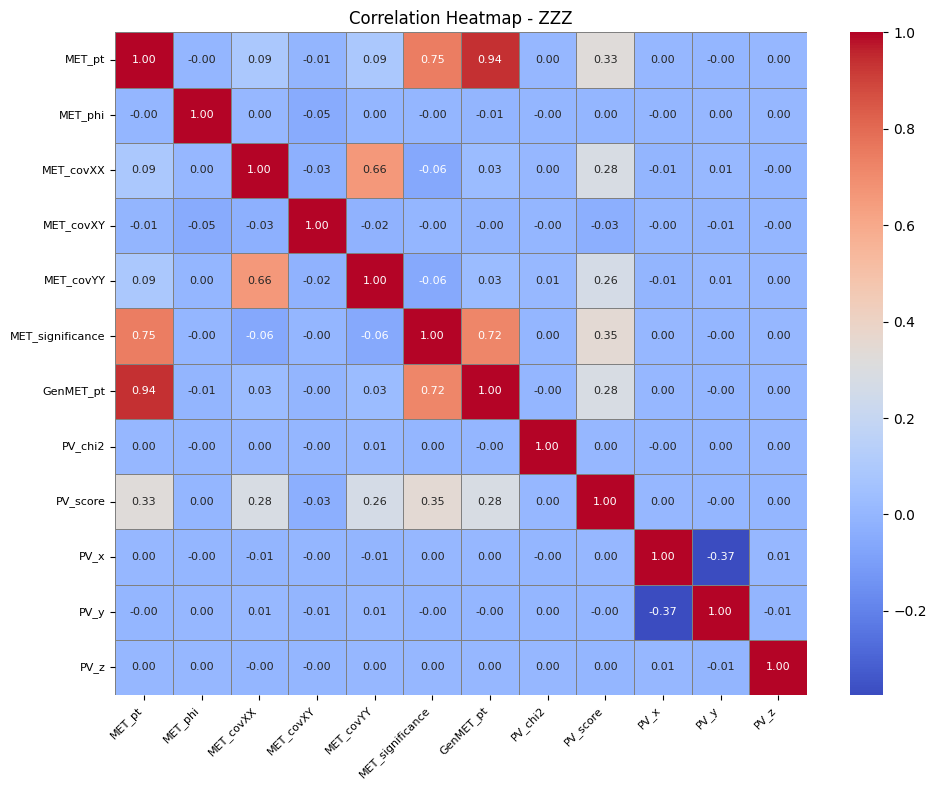

Statistics for dataset ZZZ:
    Mean MET_pt: 67.48895632481886, Median MET_pt: 46.025230407714844
    Mean GenMET_pt: 51.580507266148885, Median GenMET_pt: 25.359375


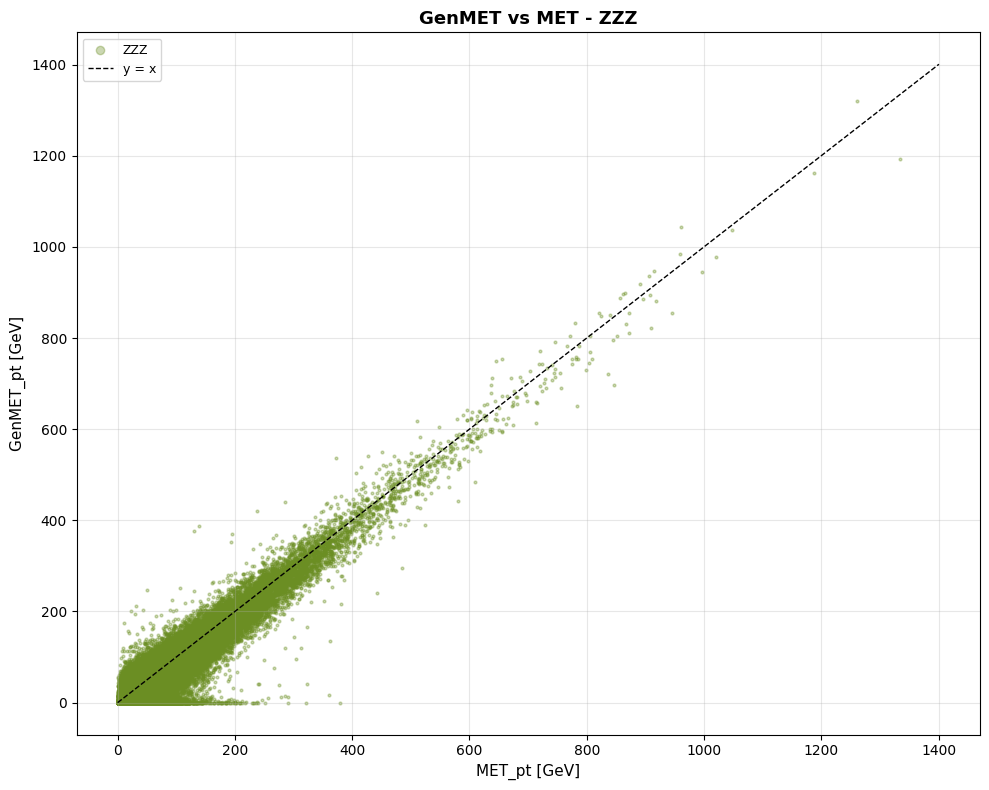

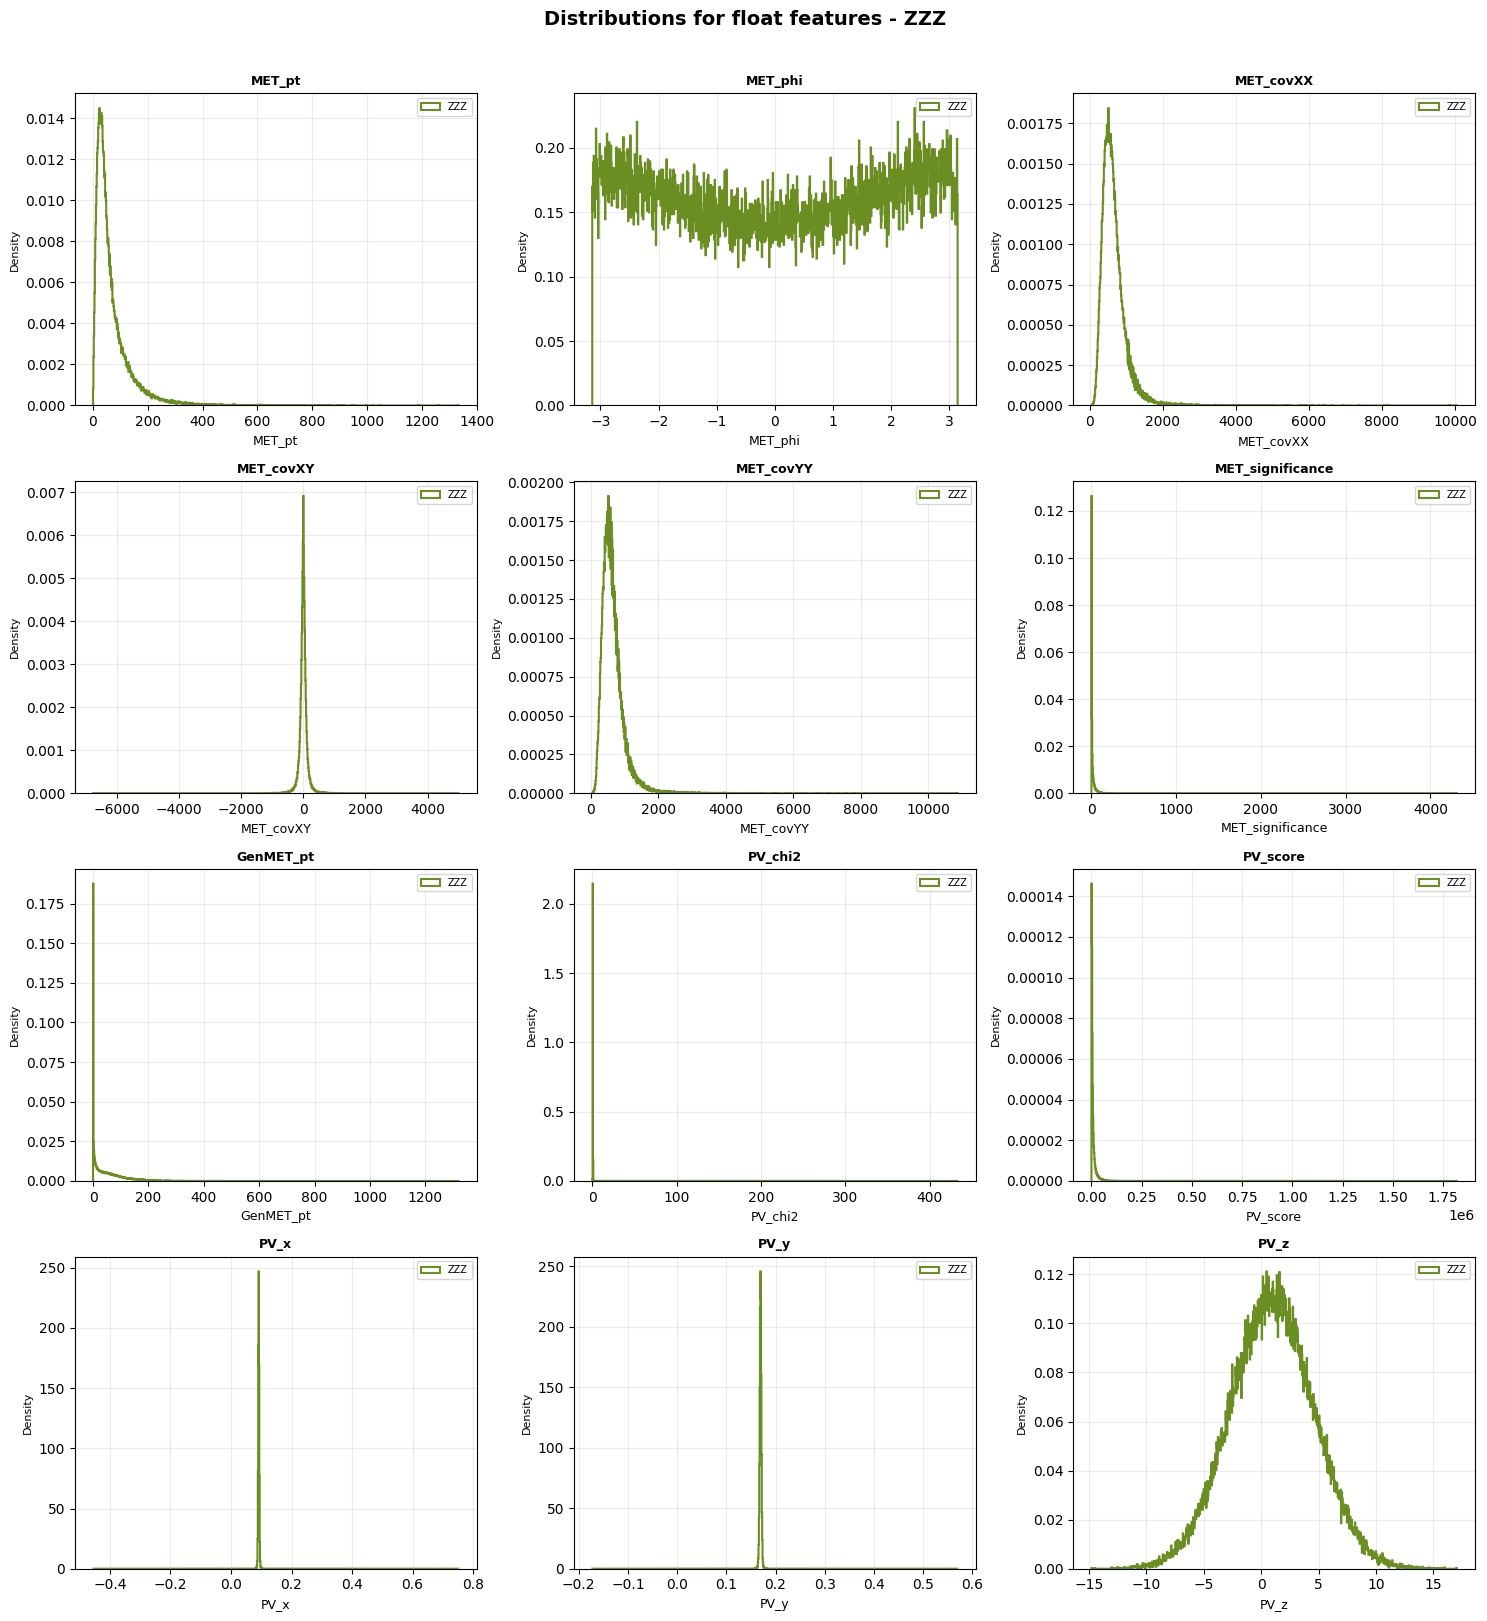

Outliers — ZZZ
  MET_pt                 8105 outliers (6.75%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX              4769 outliers (3.97%)
  MET_covXY             10047 outliers (8.37%)
  MET_covYY              4907 outliers (4.09%)
  MET_significance      14781 outliers (12.32%)
  GenMET_pt              5921 outliers (4.93%)
  PV_chi2                2671 outliers (2.23%)
  PV_score              12340 outliers (10.28%)
  PV_x                   3030 outliers (2.53%)
  PV_y                   2563 outliers (2.14%)
  PV_z                    898 outliers (0.75%)


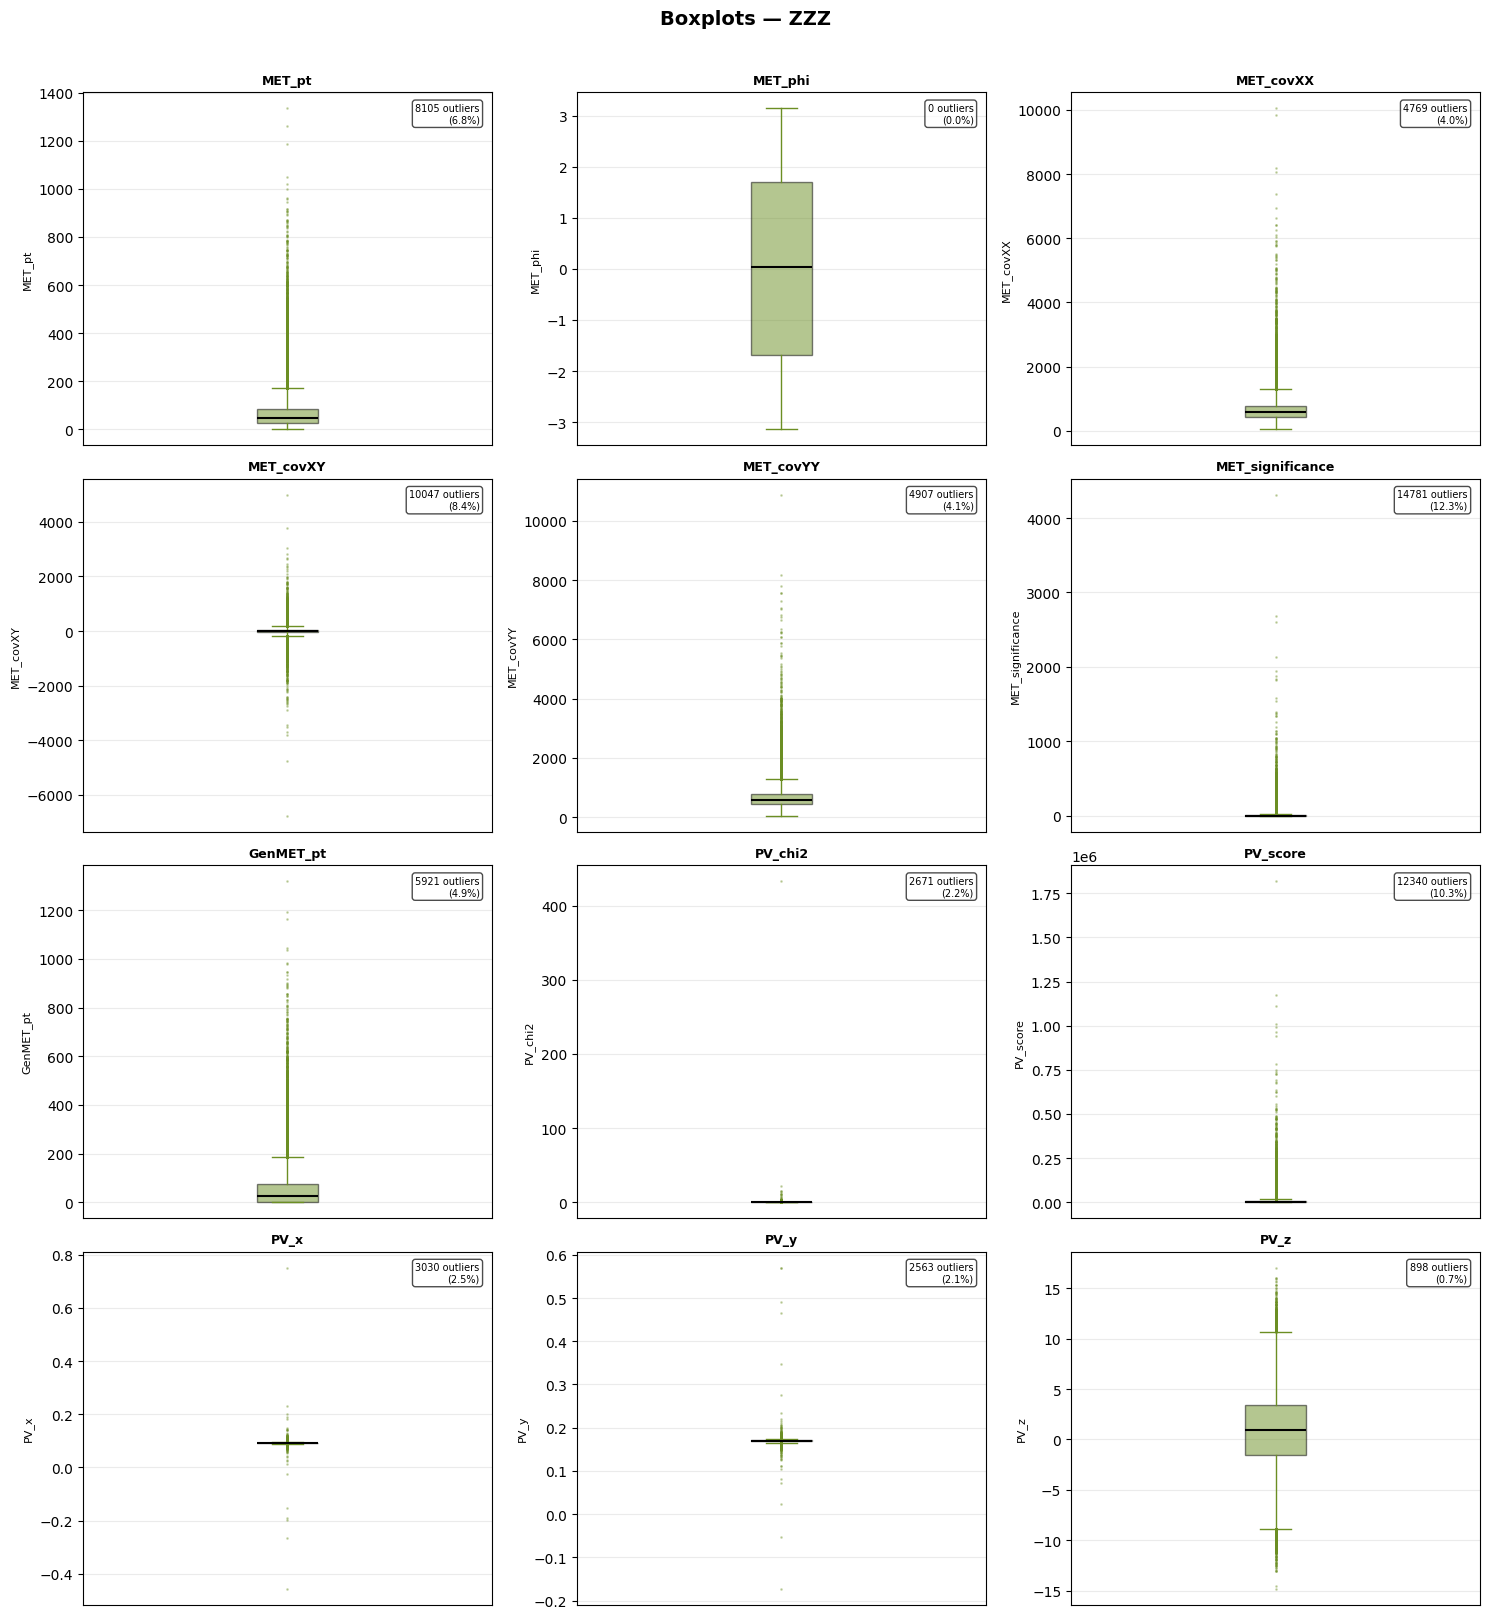

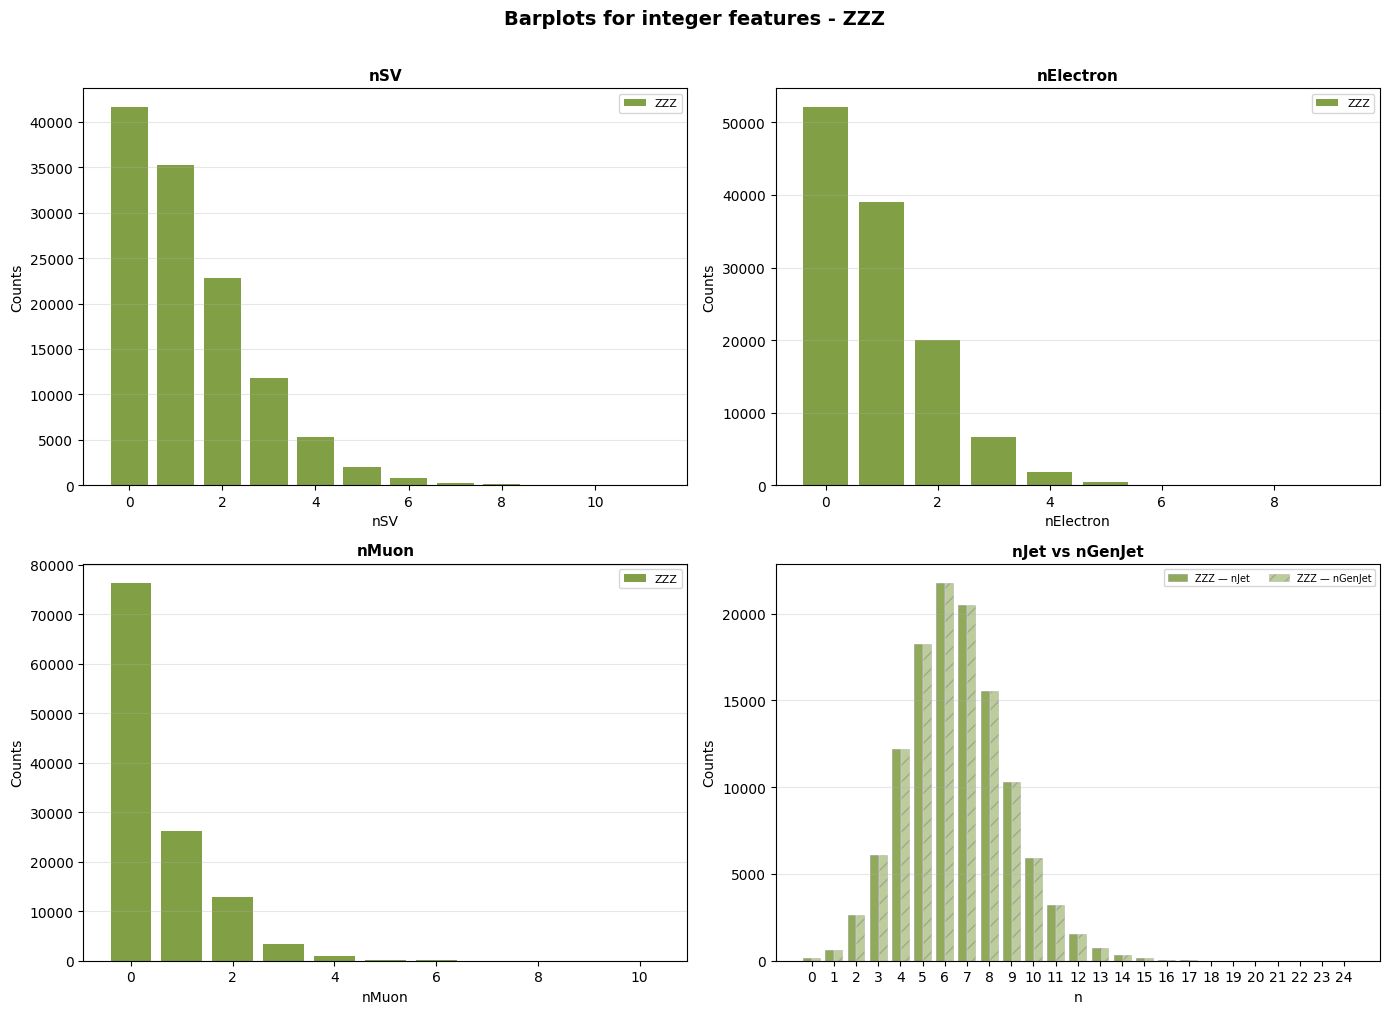

In [115]:
_correlation_heatmap(df, label)

_scatterplot_MET(df, label=label, color=color)

_data_distributions(df, label=label, color=color)

_boxplots(df, label=label, color=color)

_data_barplots(df, label=label, color=color)

---

## HToAATo2Mu2B dataset

In this process a Higgs boson decays into a couple of light pseudoscalar, each one subsequently decaying into either a couple of muons or a couple of b quarks.

From this dataset we expect:
- lower values of `MET_pt` since Neutrinos are not part of the decay chain;
- events with pairs of Muons and bJets;
- significant secondary vertices.

This, although known, is a complex process to study through ML because of its high number of features involved.

In [116]:
label = list(DATASETS.items())[2][0]
path = DATASETS.get("HToAATo2Mu2B")
color = PALETTE[2]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset HToAATo2Mu2B:
    17 features x 200000 events


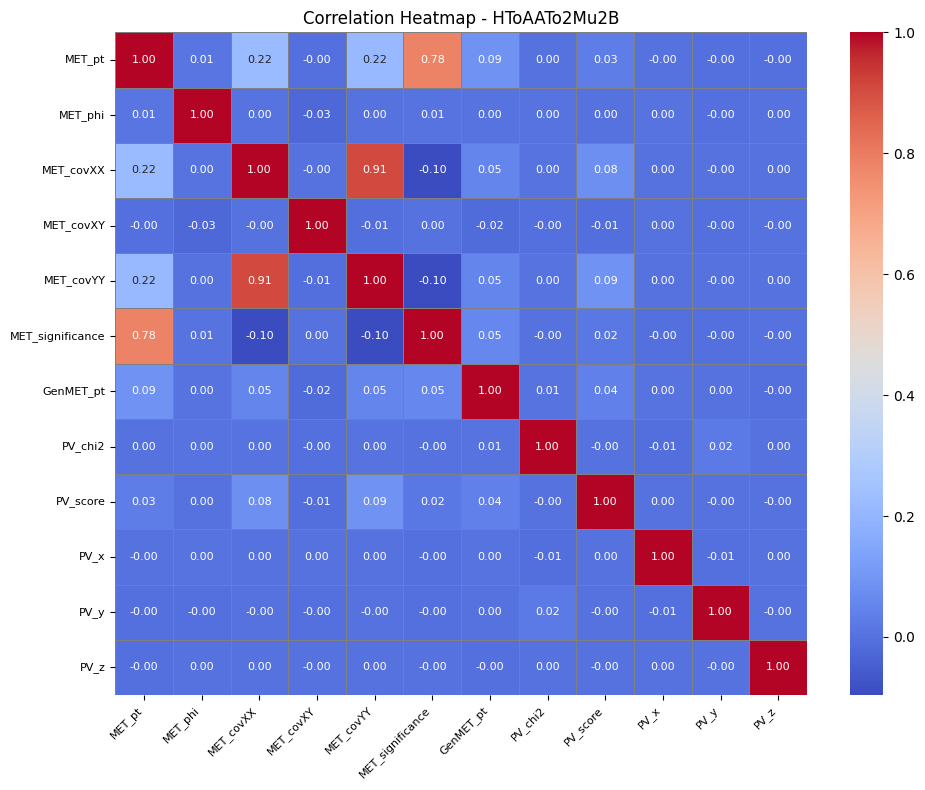

Statistics for dataset HToAATo2Mu2B:
    Mean MET_pt: 28.771739992160814, Median MET_pt: 25.45794677734375
    Mean GenMET_pt: 4.262917704530346, Median GenMET_pt: 1.5322265625


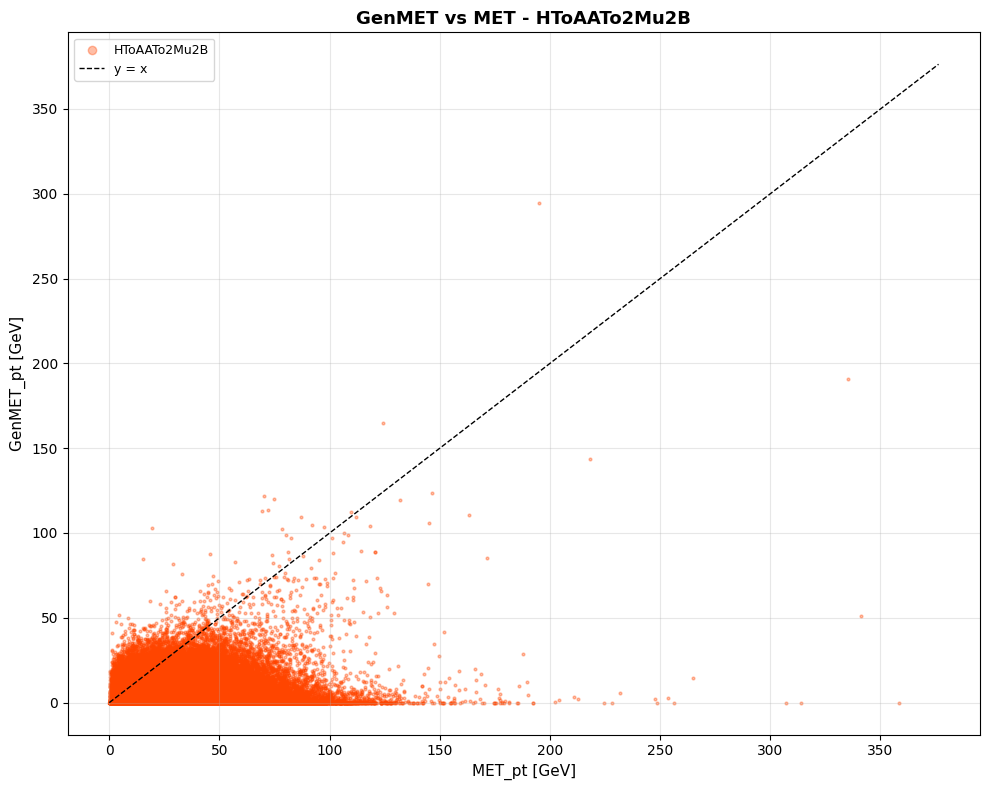

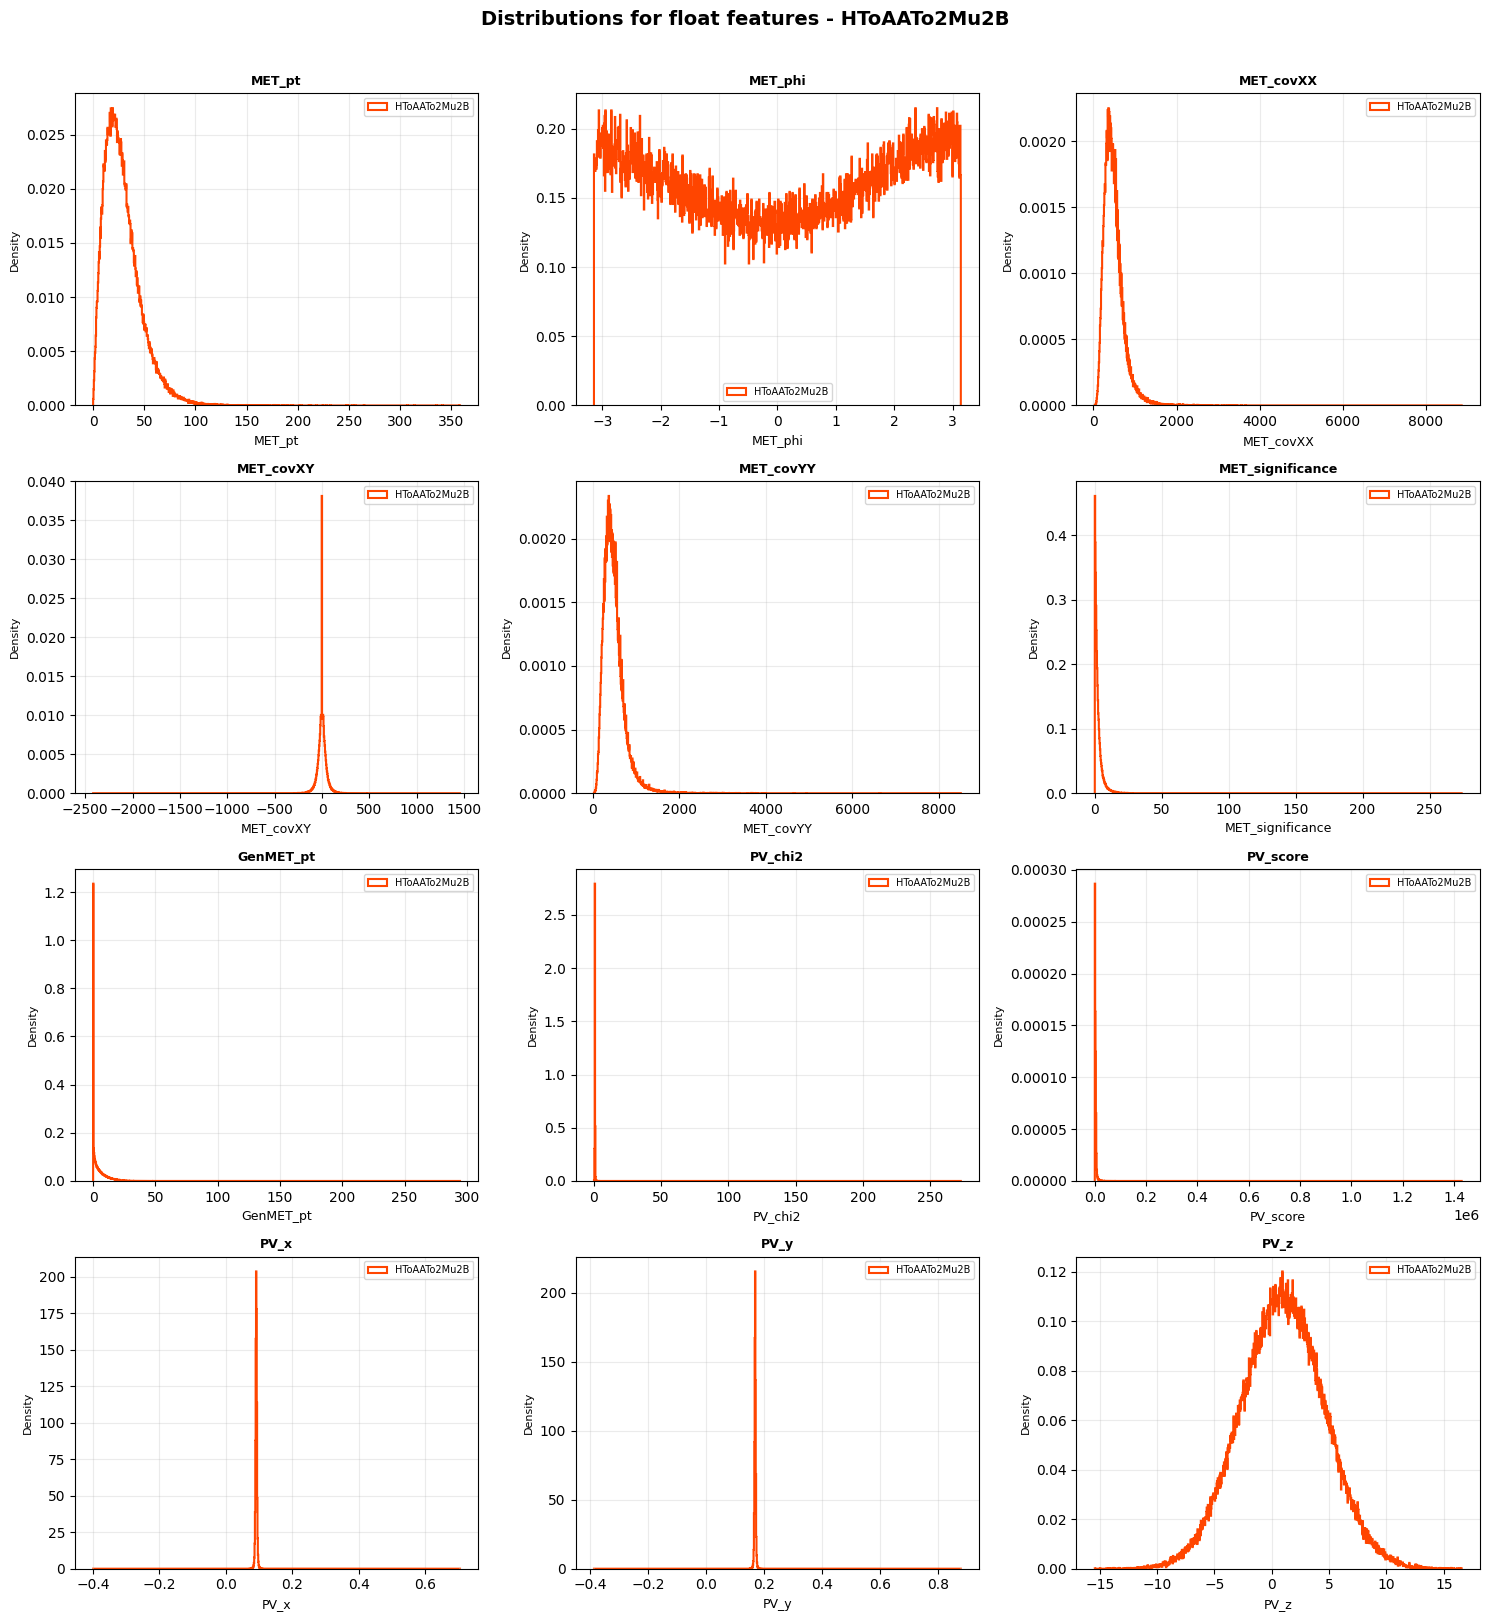

Outliers — HToAATo2Mu2B
  MET_pt                 5393 outliers (2.70%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX              7180 outliers (3.59%)
  MET_covXY             15720 outliers (7.86%)
  MET_covYY              7316 outliers (3.66%)
  MET_significance      13876 outliers (6.94%)
  GenMET_pt             13044 outliers (6.52%)
  PV_chi2                6531 outliers (3.27%)
  PV_score               7397 outliers (3.70%)
  PV_x                   7626 outliers (3.81%)
  PV_y                   6652 outliers (3.33%)
  PV_z                   1363 outliers (0.68%)


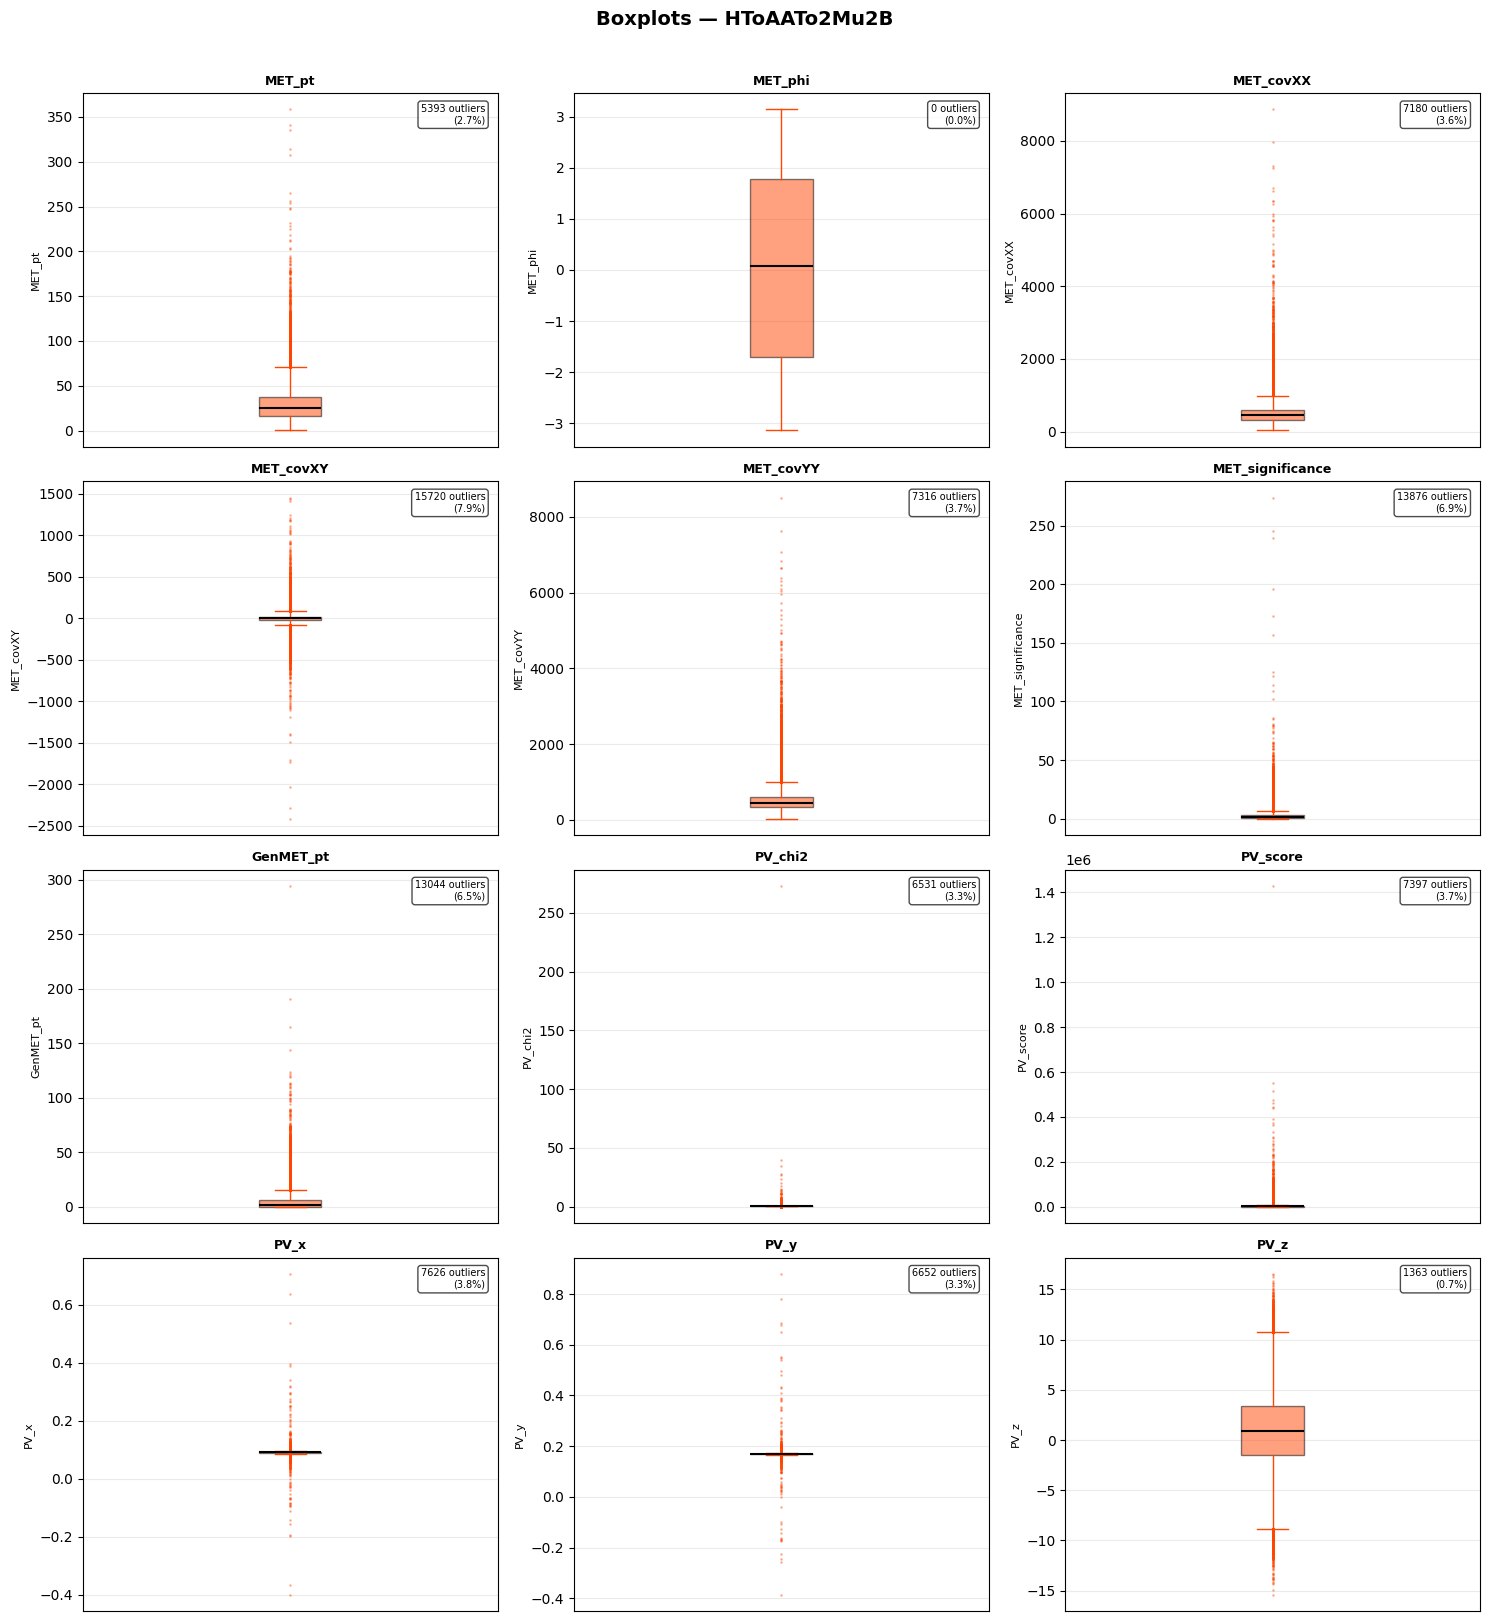

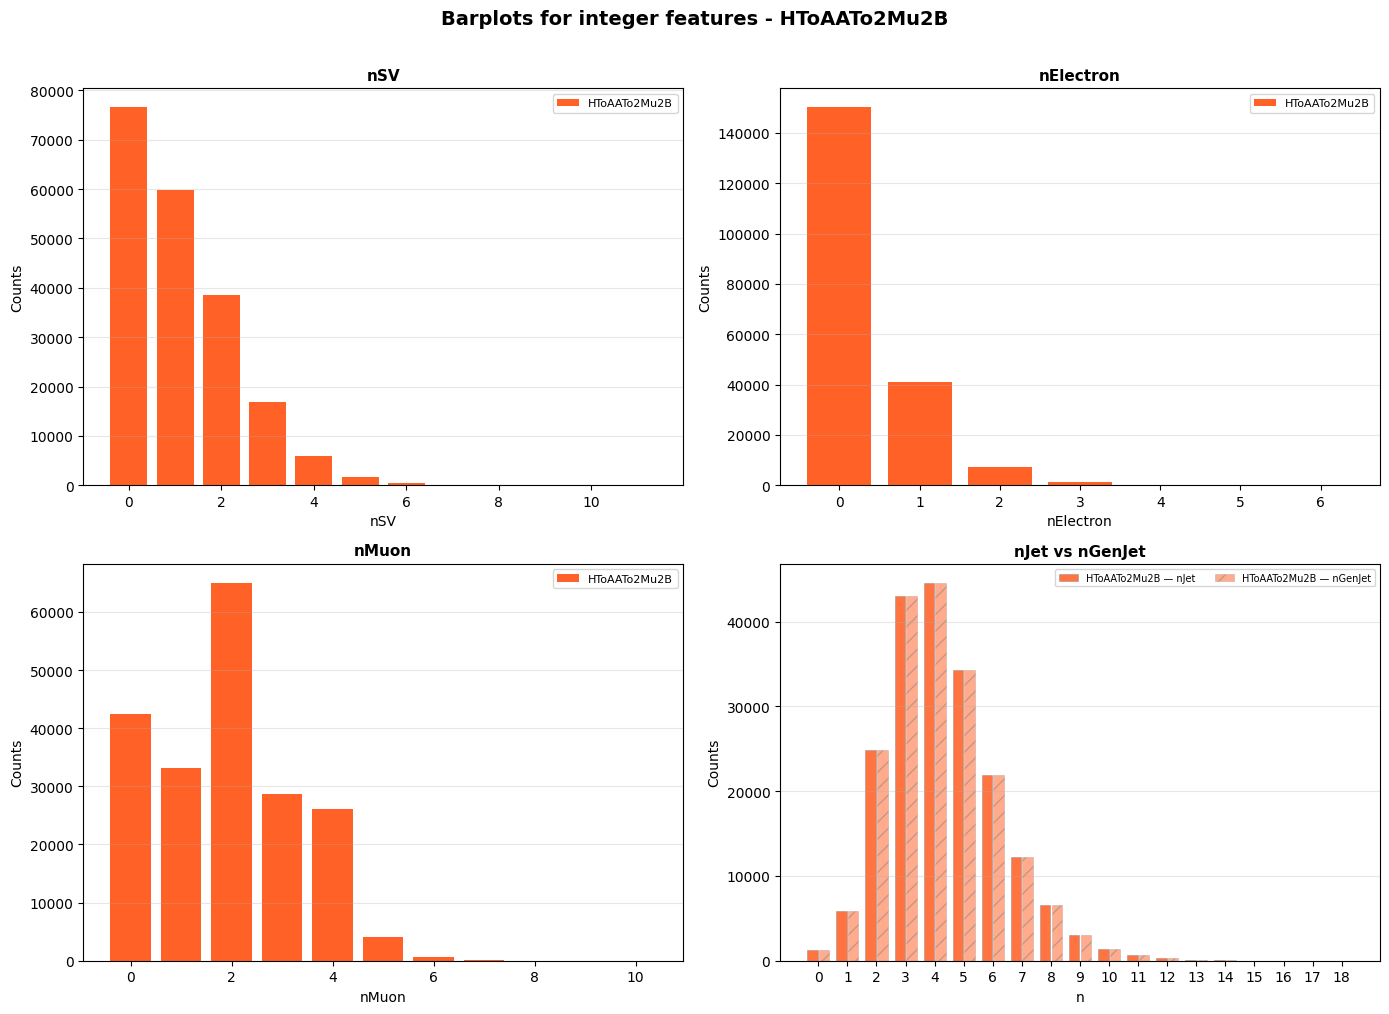

In [117]:
_correlation_heatmap(df, label)

_scatterplot_MET(df, label=label, color=color)

_data_distributions(df, label=label, color=color)

_boxplots(df, label=label, color=color)

_data_barplots(df, label=label, color=color)

We can clearly see from the `MET_pt vs GenMET_pt` graph that the revelator doesn't capture well the MET involved in this process. It will be then necessary to use features more relevant than GenMET for this purpose.